# BLE RSSI 异常检测 — 新人研修テーマC

基于BLE传感器观测的RSSI时间序列,比较监督学习与无监督学习的异常检测性能。

## Notebook 结构

1. **环境准备** - 导入库、配置
2. **数据加载与前处理** - 插补、5分钟分块
3. **特征抽出** - 滑动窗口
4. **数据可视化** - 整体概览(用于Slide 5)
5. **5个手法** - Baseline / LR / RF / IForest / OCSVM
6. **整体性能评价** - 检出率/误报率
7. **按异常类型breakdown** - 用于Slide 10
8. **结果可视化** - 用于PPT的图表


## 1. 环境准备

In [1]:
%pip install --upgrade pip
%pip install pandas numpy scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 导入库
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

# matplotlib 设置
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300  # 保存PPT用图时高分辨率
plt.rcParams['font.size'] = 11

# 如果想显示日文,设置字体(Mac系统)
# plt.rcParams['font.family'] = 'Hiragino Sans'

print("库导入完成")

库导入完成


In [3]:
# ==================== 配置参数(集中管理) ====================

# 数据路径(相对于本notebook)
DATA_PATH = 'data/bleHitachi_Labeled.log'

# 前处理
RESAMPLE_FREQ = '1s'
INTERPOLATION_METHOD = 'linear'  # 'linear' / 'ffill' / 'kalman'

# 数据分割
BLOCK_SIZE_MIN = 5  # 5分钟一块,奇偶分配train/test

# 特征抽出
WINDOW_SIZE = 30  # 滑动窗口大小(秒)

# 异常类型时间区分
ANOMALY_TYPE_BOUNDARIES = [
    (0, 150, 'Normal'),
    (150, 180, 'Short'),       # 15s closure
    (180, 210, 'Medium'),      # 30s closure
    (210, 240, 'Long'),        # 60s closure
    (240, 270, 'Gradual'),     # gradual decay
    (270, 300, 'Alternating'), # alternating
]

# 各手法的默认超参数
HPARAMS = {
    'Baseline':           {'k': 1.5},
    'LogisticRegression': {'C': 1.0, 'class_weight': 'balanced', 'max_iter': 1000},
    'RandomForest':       {'n_estimators': 100, 'max_depth': None,
                           'class_weight': 'balanced', 'random_state': 42},
    'IsolationForest':    {'n_estimators': 100, 'contamination': 0.07, 'random_state': 42},
    'OneClassSVM':        {'nu': 0.07, 'kernel': 'rbf', 'gamma': 'scale'},
}

# 输出目录
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("配置参数加载完成")

配置参数加载完成


## 2. 数据加载与前处理

- 读取CSV log
- 等间隔化(1秒)+ 插补
- 5分钟分块,奇偶分配train/test
- 按时间标记5种异常类型

In [4]:
# 读取原始数据
df_raw = pd.read_csv(
    DATA_PATH,
    header=None,
    names=['unixtime', 'device_id', 'rssi', 'temp', 'humid', 'label']
)
df_raw['datetime'] = pd.to_datetime(df_raw['unixtime'], unit='s')
df_raw = df_raw.set_index('datetime')

print(f"原始数据: {len(df_raw)} 行")
print(f"时间范围: {df_raw.index.min()} ~ {df_raw.index.max()}")
df_raw.head()

原始数据: 5243 行
时间范围: 2025-12-19 05:30:02 ~ 2025-12-19 10:29:57


,unixtime,device_id,rssi,temp,humid,label
datetime,,,,,,
2025-12-19 05:30:02,1766122202,ac233faf32a6,-57,17.109375,39.238281,0
2025-12-19 05:30:05,1766122205,ac233faf32a6,-60,17.109375,39.238281,0
2025-12-19 05:30:07,1766122207,ac233faf32a6,-57,17.109375,39.238281,0
2025-12-19 05:30:10,1766122210,ac233faf32a6,-60,17.109375,39.238281,0
2025-12-19 05:30:15,1766122215,ac233faf32a6,-64,17.109375,39.238281,0


In [5]:
# 卡尔曼滤波插补(可选用)
def kalman_interpolate(y, Q=0.5, R=2.0):
    """简易卡尔曼滤波插补"""
    n = len(y)
    x_hat = np.zeros(n)
    P = np.zeros(n)
    first_valid = y.first_valid_index()
    first_idx = y.index.get_loc(first_valid)
    x_hat[first_idx] = y.loc[first_valid]
    P[first_idx] = R
    for i in range(first_idx + 1, n):
        x_pred = x_hat[i-1]
        P_pred = P[i-1] + Q
        if not np.isnan(y.iloc[i]):
            K = P_pred / (P_pred + R)
            x_hat[i] = x_pred + K * (y.iloc[i] - x_pred)
            P[i] = (1 - K) * P_pred
        else:
            x_hat[i] = x_pred
            P[i] = P_pred
    return pd.Series(x_hat, index=y.index)


# 等间隔化 + 插补
full_idx = pd.date_range(start=df_raw.index.min(), end=df_raw.index.max(), freq=RESAMPLE_FREQ)
df = df_raw[['rssi', 'label']].reindex(full_idx)

if INTERPOLATION_METHOD == 'linear':
    df['rssi'] = df['rssi'].interpolate(method='linear')
elif INTERPOLATION_METHOD == 'ffill':
    df['rssi'] = df['rssi'].ffill()
elif INTERPOLATION_METHOD == 'kalman':
    df['rssi'] = kalman_interpolate(df['rssi'])

df['label'] = df['label'].ffill()
df = df.dropna()
df['label'] = df['label'].astype(int)
df['t_min'] = np.arange(len(df)) / 60.0  # 时间(分钟)

print(f"插补后: {len(df)} 行 (插补方法: {INTERPOLATION_METHOD})")
print(f"异常率: {df['label'].mean()*100:.2f}%")

插补后: 17996 行 (插补方法: linear)
异常率: 7.25%


In [6]:
# 5分钟分块 + train/test分配
df['block'] = (df['t_min'] // BLOCK_SIZE_MIN).astype(int)
df['split'] = df['block'].apply(lambda b: 'train' if b % 2 == 0 else 'test')

# 异常类型标记
def label_anomaly_type(t):
    for start, end, name in ANOMALY_TYPE_BOUNDARIES:
        if start <= t < end:
            return name
    return 'Unknown'
df['anomaly_type'] = df['t_min'].apply(label_anomaly_type)

print("=== Train/Test 分布 ===")
print(df['split'].value_counts())
print(f"\n训练集异常率: {df[df['split']=='train']['label'].mean()*100:.2f}%")
print(f"测试集异常率: {df[df['split']=='test']['label'].mean()*100:.2f}%")
print(f"\n=== Split × Anomaly Type ===")
print(pd.crosstab(df['anomaly_type'], df['split']))

=== Train/Test 分布 ===
split
train    9000
test     8996
Name: count, dtype: int64

训练集异常率: 6.86%
测试集异常率: 7.64%

=== Split × Anomaly Type ===
split         test  train
anomaly_type             
Alternating    896    900
Gradual        900    900
Long           900    900
Medium         900    900
Normal        4500   4500
Short          900    900


## 3. 特征抽出

每个滑动窗口(30秒)抽出7个统计特征:
- mean, std, min, max, range, last(窗口最后值), slope(窗口首尾差)

窗口标签 = 窗口最后一点的标签(因果性,只用过去信息)

In [7]:
def extract_window_features(rssi_series, window_size):
    """对每个滑动窗口抽出统计特征"""
    rssi = rssi_series.values
    n = len(rssi)
    out_len = n - window_size + 1
    features = {
        'mean':  np.zeros(out_len),
        'std':   np.zeros(out_len),
        'min':   np.zeros(out_len),
        'max':   np.zeros(out_len),
        'range': np.zeros(out_len),
        'last':  np.zeros(out_len),
        'slope': np.zeros(out_len),
    }
    for i in range(window_size, n + 1):
        win = rssi[i - window_size:i]
        idx = i - window_size
        features['mean'][idx]  = win.mean()
        features['std'][idx]   = win.std()
        features['min'][idx]   = win.min()
        features['max'][idx]   = win.max()
        features['range'][idx] = win.max() - win.min()
        features['last'][idx]  = win[-1]
        features['slope'][idx] = win[-1] - win[0]
    return pd.DataFrame(features)


# 抽出特征
X_all = extract_window_features(df['rssi'], WINDOW_SIZE)
y_all = df['label'].iloc[WINDOW_SIZE - 1:].values
split_all = df['split'].iloc[WINDOW_SIZE - 1:].values
type_all = df['anomaly_type'].iloc[WINDOW_SIZE - 1:].values

# 分割 train/test
train_mask = split_all == 'train'
test_mask = split_all == 'test'

X_train = X_all[train_mask].values
y_train = y_all[train_mask]
X_test = X_all[test_mask].values
y_test = y_all[test_mask]
type_test = type_all[test_mask]

print(f"X_train: {X_train.shape}, 异常率 {y_train.mean()*100:.2f}%")
print(f"X_test: {X_test.shape}, 异常率 {y_test.mean()*100:.2f}%")
print(f"\n特征列: {list(X_all.columns)}")

X_train: (8971, 7), 异常率 6.88%
X_test: (8996, 7), 异常率 7.64%

特征列: ['mean', 'std', 'min', 'max', 'range', 'last', 'slope']


## 4. 数据可视化(Slide 5 用图)

- RSSI时间序列(正常/异常着色)
- 5种异常类型的时间分布
- Train/Test分块的可视化

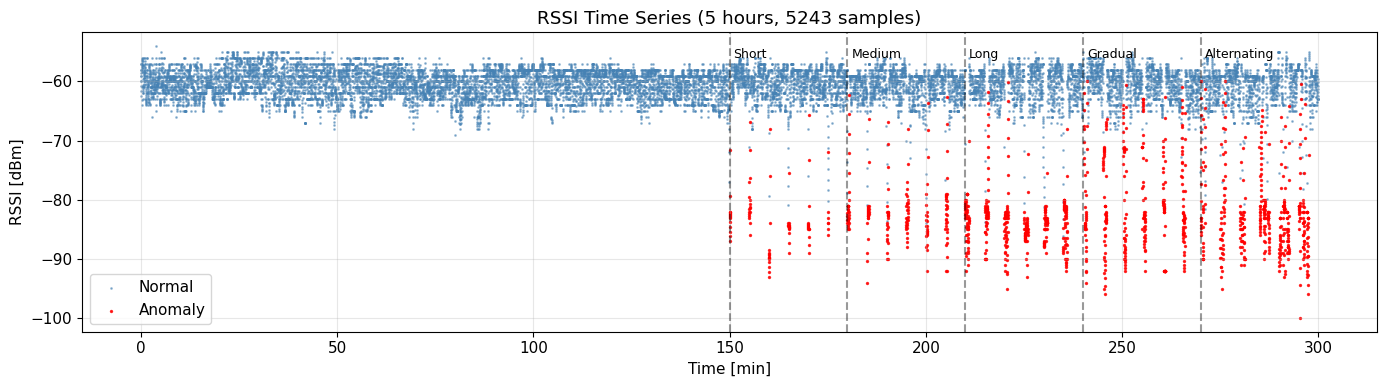

In [8]:
# RSSI时间序列概览
fig, ax = plt.subplots(figsize=(14, 4))

normal = df[df['label'] == 0]
anom = df[df['label'] == 1]
ax.scatter(normal['t_min'], normal['rssi'], s=1, c='steelblue', alpha=0.5, label='Normal')
ax.scatter(anom['t_min'], anom['rssi'], s=2, c='red', alpha=0.8, label='Anomaly')

# 异常类型边界
for boundary, label in [(150, 'Short'), (180, 'Medium'), (210, 'Long'),
                         (240, 'Gradual'), (270, 'Alternating')]:
    ax.axvline(x=boundary, color='black', alpha=0.4, linestyle='--')
    ax.text(boundary + 1, -56, label, fontsize=9)

ax.set_xlabel('Time [min]')
ax.set_ylabel('RSSI [dBm]')
ax.set_title('RSSI Time Series (5 hours, 5243 samples)')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rssi_overview.png', dpi=300, bbox_inches='tight')
plt.show()

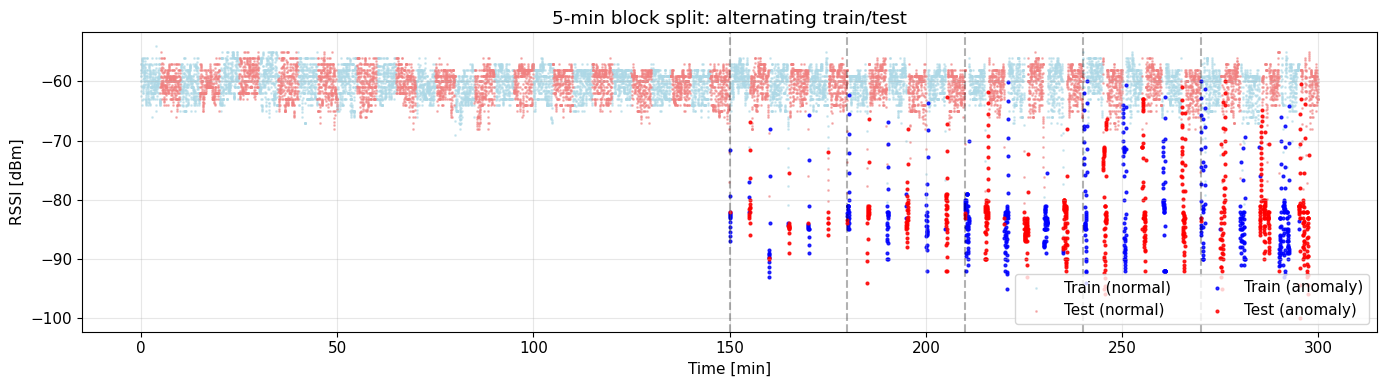

In [9]:
# Train/Test 分块的可视化
fig, ax = plt.subplots(figsize=(14, 4))

train_data = df[df['split'] == 'train']
test_data = df[df['split'] == 'test']
ax.scatter(train_data['t_min'], train_data['rssi'], s=1, c='lightblue', alpha=0.5, label='Train (normal)')
ax.scatter(test_data['t_min'], test_data['rssi'], s=1, c='lightcoral', alpha=0.5, label='Test (normal)')

train_anom = train_data[train_data['label'] == 1]
test_anom = test_data[test_data['label'] == 1]
ax.scatter(train_anom['t_min'], train_anom['rssi'], s=4, c='blue', alpha=0.8, label='Train (anomaly)')
ax.scatter(test_anom['t_min'], test_anom['rssi'], s=4, c='red', alpha=0.8, label='Test (anomaly)')

for boundary in [150, 180, 210, 240, 270]:
    ax.axvline(x=boundary, color='black', alpha=0.3, linestyle='--')

ax.set_xlabel('Time [min]')
ax.set_ylabel('RSSI [dBm]')
ax.set_title(f'5-min block split: alternating train/test')
ax.legend(loc='lower right', ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. 5个异常检测手法

- **Baseline**: 统计阈值法 (μ - k·σ)
- **LogReg**: Logistic Regression (监督)
- **RandomForest**: Random Forest (监督)
- **IsolationForest**: Isolation Forest (无监督)
- **OneClassSVM**: One-Class SVM (无监督)

In [10]:
# Baseline: 统计阈值法
class BaselineThreshold:
    name = 'Baseline'
    def __init__(self, k=1.5):
        self.k = k
        self.threshold = None
    def fit(self, X_train, y_train):
        # 用训练集中label==0的窗口的mean
        normal_means = X_train[y_train == 0, 0]  # 第0列是mean
        mu = normal_means.mean()
        sigma = normal_means.std()
        self.threshold = mu - self.k * sigma
        return self
    def predict(self, X_test):
        return (X_test[:, 0] < self.threshold).astype(int)


# 监督学习①: Logistic Regression
class LogRegMethod:
    name = 'LogReg'
    def __init__(self, C=1.0, class_weight='balanced', max_iter=1000):
        self.C = C
        self.class_weight = class_weight
        self.max_iter = max_iter
    def fit(self, X_train, y_train):
        self.scaler = StandardScaler()
        X_train_s = self.scaler.fit_transform(X_train)
        self.model = LogisticRegression(
            C=self.C, class_weight=self.class_weight, max_iter=self.max_iter
        )
        self.model.fit(X_train_s, y_train)
        return self
    def predict(self, X_test):
        return self.model.predict(self.scaler.transform(X_test))


# 监督学习②: Random Forest
class RandomForestMethod:
    name = 'RandomForest'
    def __init__(self, n_estimators=100, max_depth=None,
                 class_weight='balanced', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.class_weight = class_weight
        self.random_state = random_state
    def fit(self, X_train, y_train):
        self.model = RandomForestClassifier(
            n_estimators=self.n_estimators, max_depth=self.max_depth,
            class_weight=self.class_weight, random_state=self.random_state
        )
        self.model.fit(X_train, y_train)
        return self
    def predict(self, X_test):
        return self.model.predict(X_test)


# 无监督学习③: Isolation Forest
class IsolationForestMethod:
    name = 'IsolationForest'
    def __init__(self, n_estimators=100, contamination=0.07, random_state=42):
        self.n_estimators = n_estimators
        self.contamination = contamination
        self.random_state = random_state
    def fit(self, X_train, y_train=None):
        # 无监督: 不用y_train
        self.scaler = StandardScaler()
        X_train_s = self.scaler.fit_transform(X_train)
        self.model = IsolationForest(
            n_estimators=self.n_estimators,
            contamination=self.contamination,
            random_state=self.random_state
        )
        self.model.fit(X_train_s)
        return self
    def predict(self, X_test):
        X_test_s = self.scaler.transform(X_test)
        return (self.model.predict(X_test_s) == -1).astype(int)


# 无监督学习④: One-Class SVM
class OneClassSVMMethod:
    name = 'OneClassSVM'
    def __init__(self, nu=0.07, kernel='rbf', gamma='scale'):
        self.nu = nu
        self.kernel = kernel
        self.gamma = gamma
    def fit(self, X_train, y_train=None):
        # OC-SVM: 仅用正常数据训练
        self.scaler = StandardScaler()
        X_train_s = self.scaler.fit_transform(X_train)
        if y_train is not None:
            X_train_normal = X_train_s[y_train == 0]
        else:
            X_train_normal = X_train_s
        self.model = OneClassSVM(nu=self.nu, kernel=self.kernel, gamma=self.gamma)
        self.model.fit(X_train_normal)
        return self
    def predict(self, X_test):
        X_test_s = self.scaler.transform(X_test)
        return (self.model.predict(X_test_s) == -1).astype(int)


print("5个手法的类定义完成")

5个手法的类定义完成


In [11]:
# 训练所有手法 + 预测
methods_list = [
    BaselineThreshold(**HPARAMS['Baseline']),
    LogRegMethod(**HPARAMS['LogisticRegression']),
    RandomForestMethod(**HPARAMS['RandomForest']),
    IsolationForestMethod(**HPARAMS['IsolationForest']),
    OneClassSVMMethod(**HPARAMS['OneClassSVM']),
]

predictions = {}
for method in methods_list:
    method.fit(X_train, y_train)
    y_pred = method.predict(X_test)
    predictions[method.name] = y_pred
    print(f"  ✓ {method.name}: 异常预测数 {y_pred.sum()}")

  ✓ Baseline: 异常预测数 986
  ✓ LogReg: 异常预测数 820


/Users/zdd/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/zdd/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/zdd/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/zdd/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/zdd/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/zdd/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in 

  ✓ RandomForest: 异常预测数 689
  ✓ IsolationForest: 异常预测数 664
  ✓ OneClassSVM: 异常预测数 1240


## 6. 整体性能评价

只用两个指标:
- **检出率 (Detection Rate)** = TP / (TP + FN)
- **误报率 (False Alarm Rate)** = FP / (FP + TN)

In [12]:
def evaluate(y_true, y_pred):
    """返回检出率、误报率、混同矩阵的成分"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    TP = int(((y_true == 1) & (y_pred == 1)).sum())
    FN = int(((y_true == 1) & (y_pred == 0)).sum())
    FP = int(((y_true == 0) & (y_pred == 1)).sum())
    TN = int(((y_true == 0) & (y_pred == 0)).sum())
    dr = TP / (TP + FN) if (TP + FN) > 0 else 0
    far = FP / (FP + TN) if (FP + TN) > 0 else 0
    return {'detection_rate': dr, 'false_alarm_rate': far,
            'TP': TP, 'FN': FN, 'FP': FP, 'TN': TN}


# 各手法的整体评价
results = {name: evaluate(y_test, y_pred) for name, y_pred in predictions.items()}

# 整理成表
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        '手法': name,
        '検出率 [%]': r['detection_rate'] * 100,
        '誤報率 [%]': r['false_alarm_rate'] * 100,
        'TP': r['TP'], 'FN': r['FN'], 'FP': r['FP'], 'TN': r['TN'],
    })
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.round(2)
summary_df.to_csv(f'{OUTPUT_DIR}/overall_results.csv', index=False)
summary_df

,手法,検出率 [%],誤報率 [%],TP,FN,FP,TN
0,Baseline,83.26,4.98,572,115,414,7895
1,LogReg,99.13,1.67,681,6,139,8170
2,RandomForest,95.20,0.42,654,33,35,8274
3,IsolationForest,67.98,2.37,467,220,197,8112
4,OneClassSVM,100.00,6.66,687,0,553,7756


## 7. 按异常类型breakdown(Slide 10 用)

5种异常类型各自的检出率:Short / Medium / Long / Gradual / Alternating

In [13]:
def evaluate_by_type(y_true, y_pred, types):
    """按异常类型计算检出率"""
    results = {}
    for t in sorted(set(types)):
        if t == 'Normal':
            continue
        mask = types == t
        sub_true = y_true[mask]
        sub_pred = y_pred[mask]
        n_anom = (sub_true == 1).sum()
        n_detected = ((sub_true == 1) & (sub_pred == 1)).sum()
        results[t] = (n_detected / n_anom * 100) if n_anom > 0 else 0
    return results


# 各手法的按类型breakdown
breakdown = {}
for name, y_pred in predictions.items():
    breakdown[name] = evaluate_by_type(y_test, y_pred, type_test)

breakdown_df = pd.DataFrame(breakdown).T
# 调整列顺序: Short / Medium / Long / Gradual / Alternating
column_order = ['Short', 'Medium', 'Long', 'Gradual', 'Alternating']
breakdown_df = breakdown_df[column_order]
breakdown_df = breakdown_df.round(2)
breakdown_df.to_csv(f'{OUTPUT_DIR}/breakdown_results.csv')
print("按异常类型的检出率 [%]:")
breakdown_df

按异常类型的检出率 [%]:


,Short,Medium,Long,Gradual,Alternating
Baseline,69.23,83.91,93.57,73.01,85.40
LogReg,100.00,100.00,99.42,97.55,99.56
RandomForest,100.00,98.85,98.83,88.96,94.69
IsolationForest,43.59,63.22,84.80,67.48,61.95
OneClassSVM,100.00,100.00,100.00,100.00,100.00


## 8. PPT用结果图

为Slide 10准备的可视化:
- 检出率 vs 误报率 散点图(5个手法5个点)
- 按异常类型breakdown的柱状图

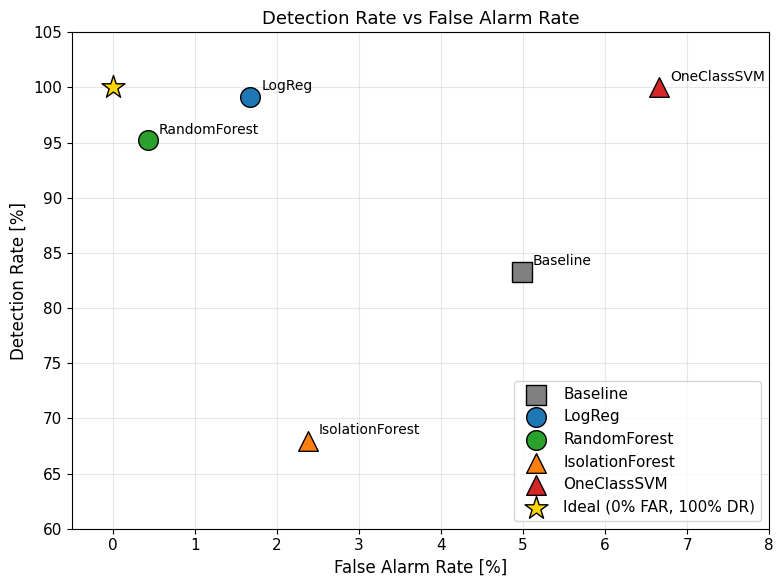

In [14]:
# 检出率 vs 误报率 散点图
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Baseline': 'gray', 'LogReg': 'tab:blue', 'RandomForest': 'tab:green',
          'IsolationForest': 'tab:orange', 'OneClassSVM': 'tab:red'}
markers = {'Baseline': 's', 'LogReg': 'o', 'RandomForest': 'o',
           'IsolationForest': '^', 'OneClassSVM': '^'}

for name, r in results.items():
    ax.scatter(r['false_alarm_rate']*100, r['detection_rate']*100,
               s=200, c=colors[name], marker=markers[name],
               label=name, edgecolors='black', linewidth=1, zorder=5)
    ax.annotate(name,
                (r['false_alarm_rate']*100, r['detection_rate']*100),
                xytext=(8, 5), textcoords='offset points', fontsize=10)

# 理想点
ax.scatter(0, 100, s=300, marker='*', c='gold', edgecolors='black',
           label='Ideal (0% FAR, 100% DR)', zorder=5)

ax.set_xlabel('False Alarm Rate [%]', fontsize=12)
ax.set_ylabel('Detection Rate [%]', fontsize=12)
ax.set_title('Detection Rate vs False Alarm Rate', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, 8)
ax.set_ylim(60, 105)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/dr_vs_far_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

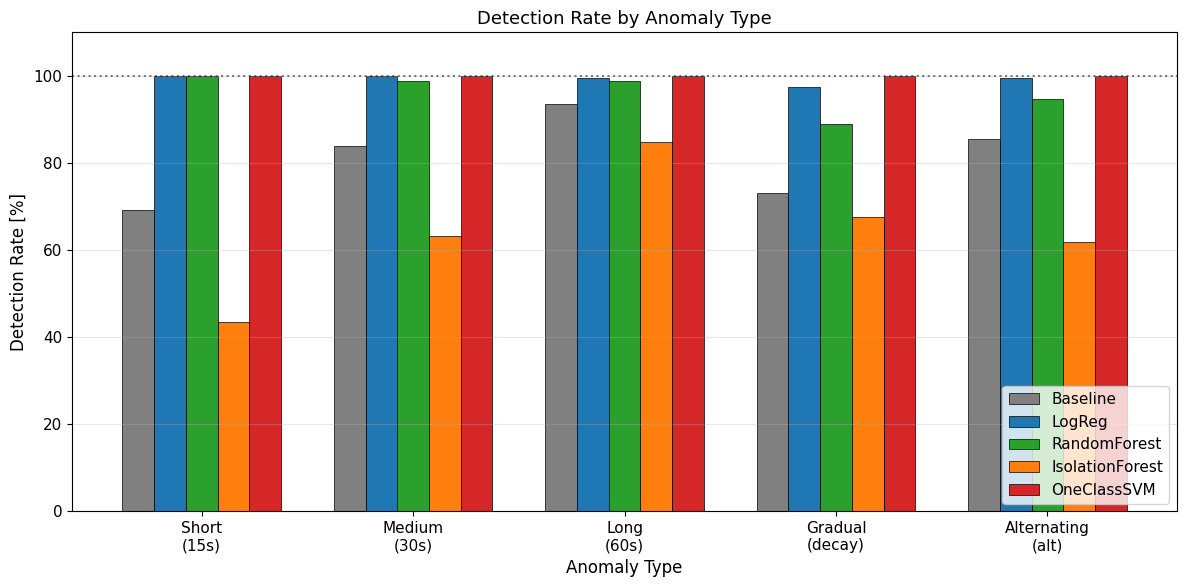

In [15]:
# 按异常类型breakdown的柱状图
fig, ax = plt.subplots(figsize=(12, 6))

methods_names = list(breakdown.keys())
types = column_order
n_methods = len(methods_names)
n_types = len(types)
x = np.arange(n_types)
width = 0.15

for i, name in enumerate(methods_names):
    values = [breakdown[name][t] for t in types]
    ax.bar(x + i*width, values, width, label=name, color=colors[name],
           edgecolor='black', linewidth=0.5)

ax.set_xlabel('Anomaly Type', fontsize=12)
ax.set_ylabel('Detection Rate [%]', fontsize=12)
ax.set_title('Detection Rate by Anomaly Type', fontsize=13)
ax.set_xticks(x + width * (n_methods-1) / 2)
ax.set_xticklabels([f'{t}\n({s})' for t, s in zip(types, ['15s','30s','60s','decay','alt'])])
ax.legend(loc='lower right')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=100, color='black', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/breakdown_bars.png', dpi=300, bbox_inches='tight')
plt.show()

## 完成

到这里基线结果都跑出来了。后续可以:

1. **修改 `INTERPOLATION_METHOD`** → 比较不同插补方法
2. **修改 `WINDOW_SIZE`** → 看窗口大小对结果的影响
3. **添加超参数扫描** → 用于Slide 7和9的图
4. **改 `HPARAMS`** → 调单个手法的参数

所有图都保存在 `outputs/` 目录,分辨率300dpi可以直接放进PPT。